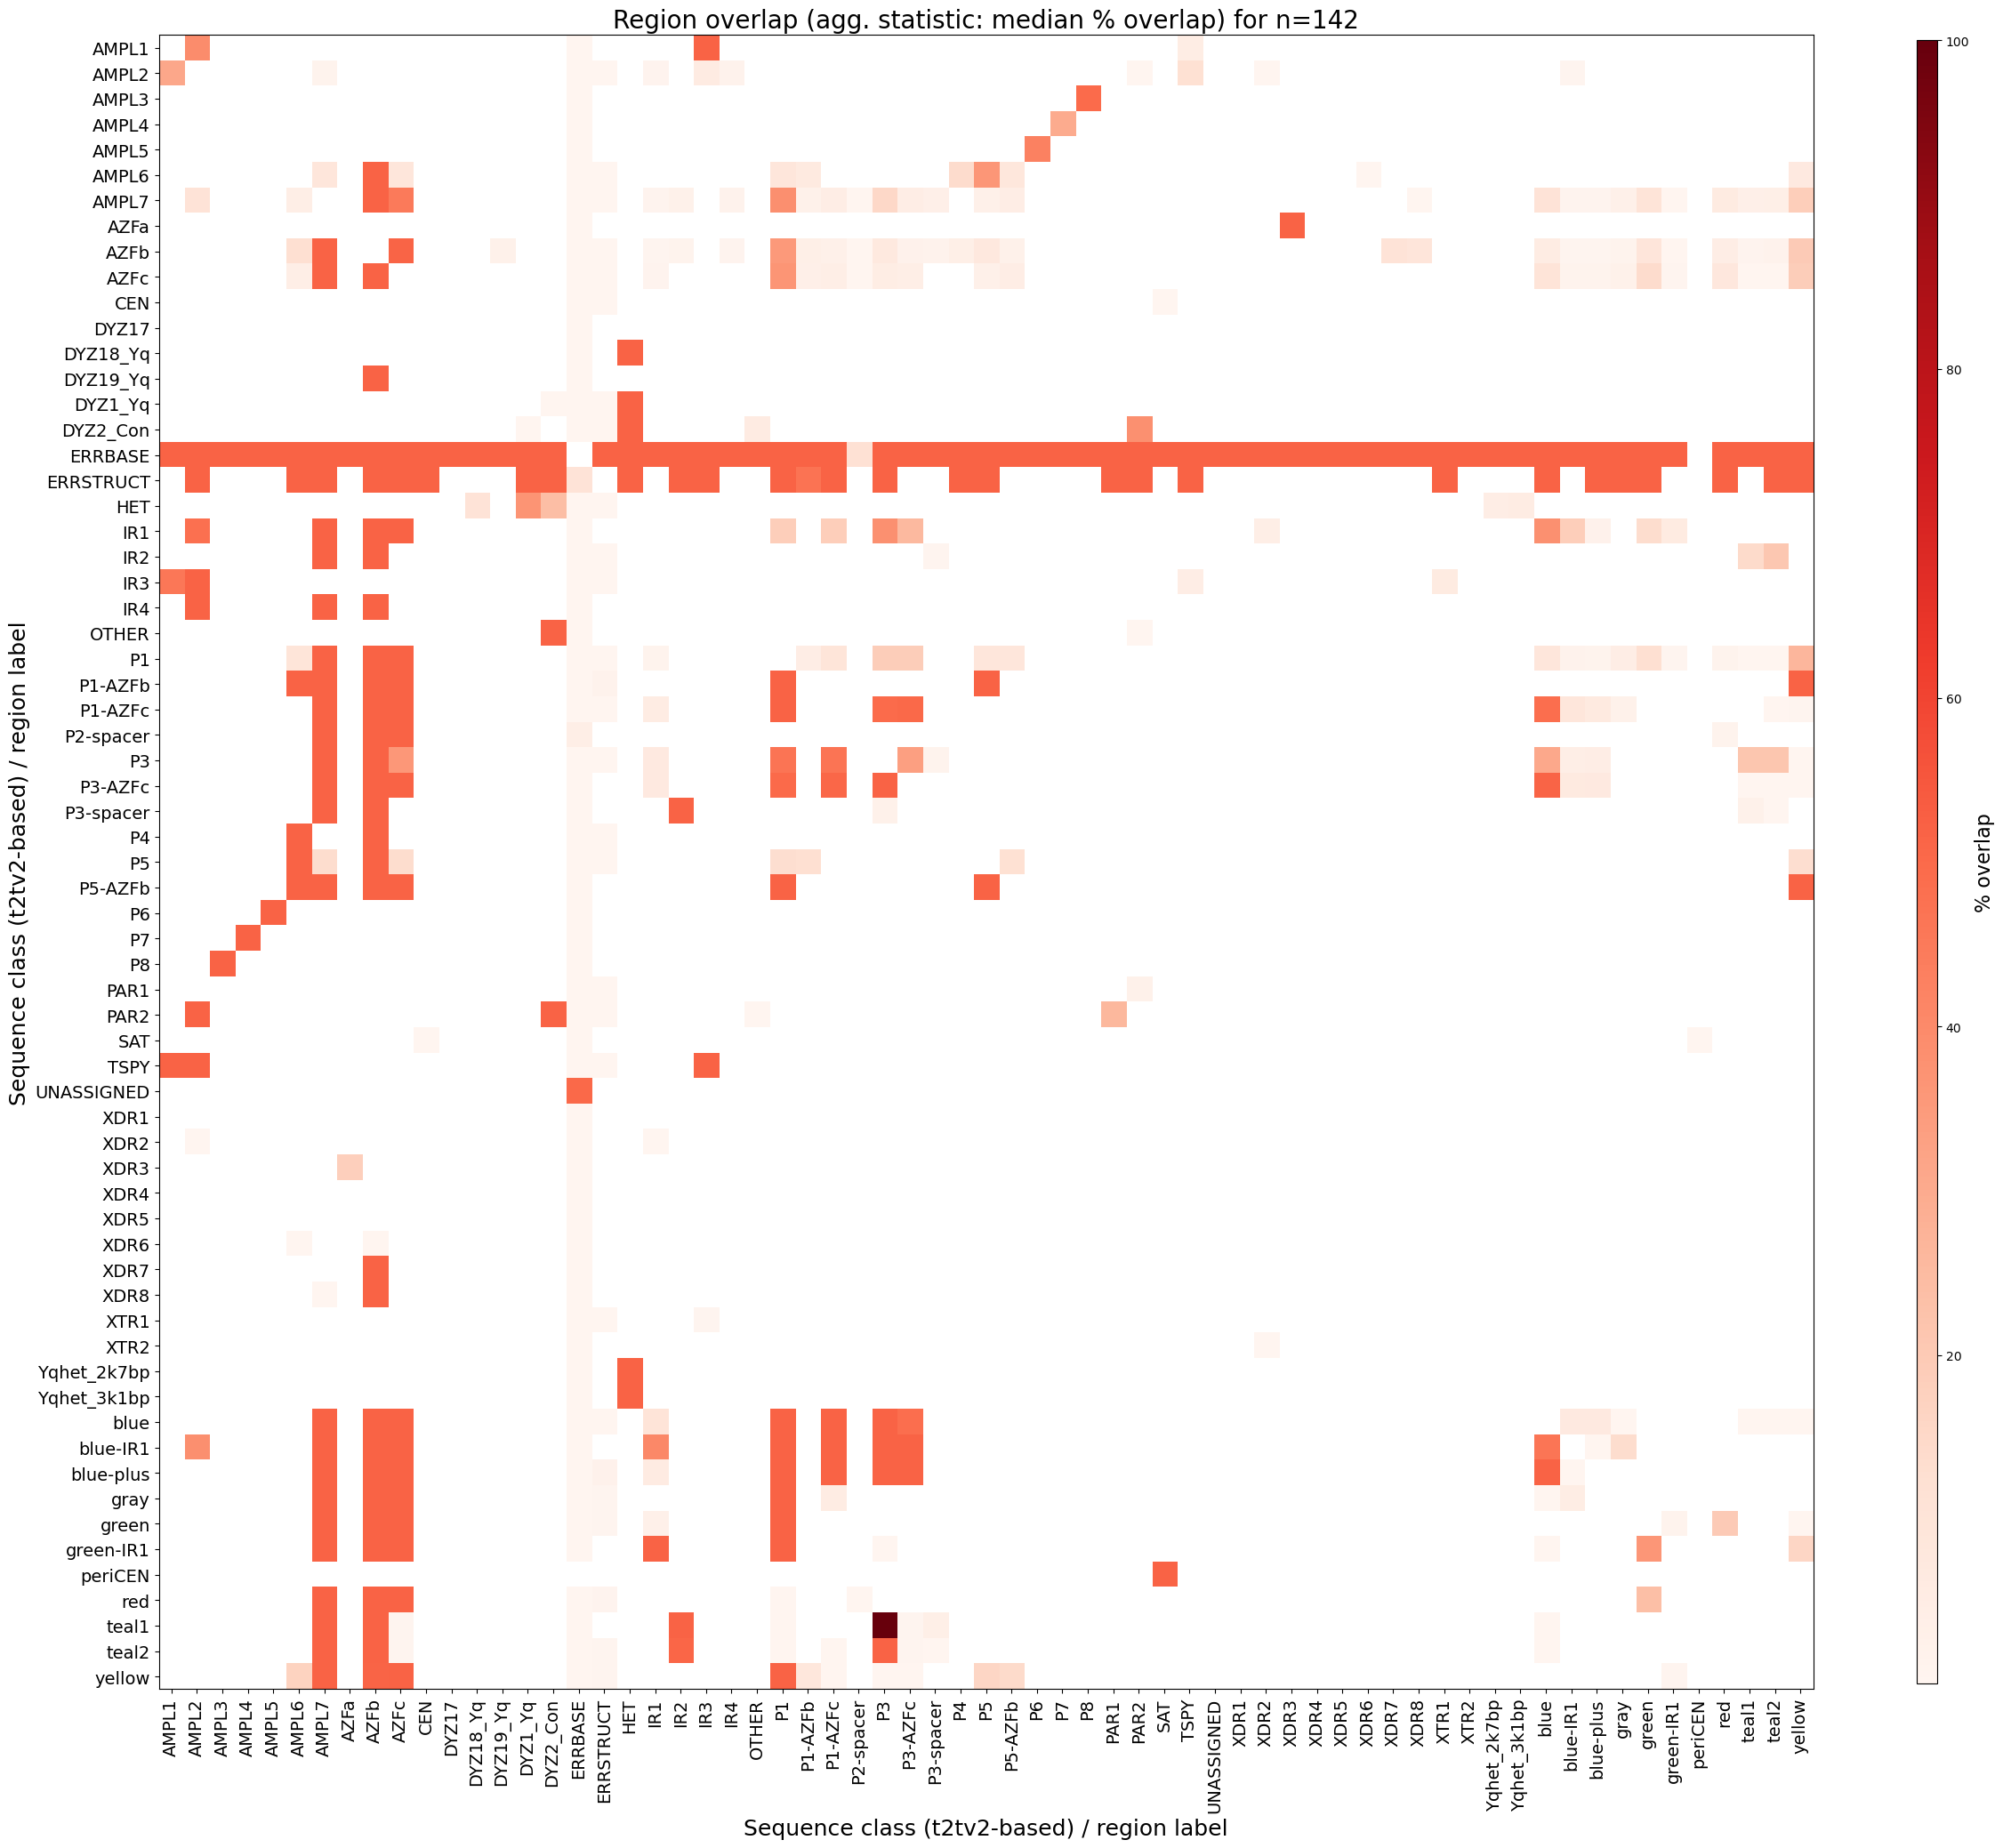

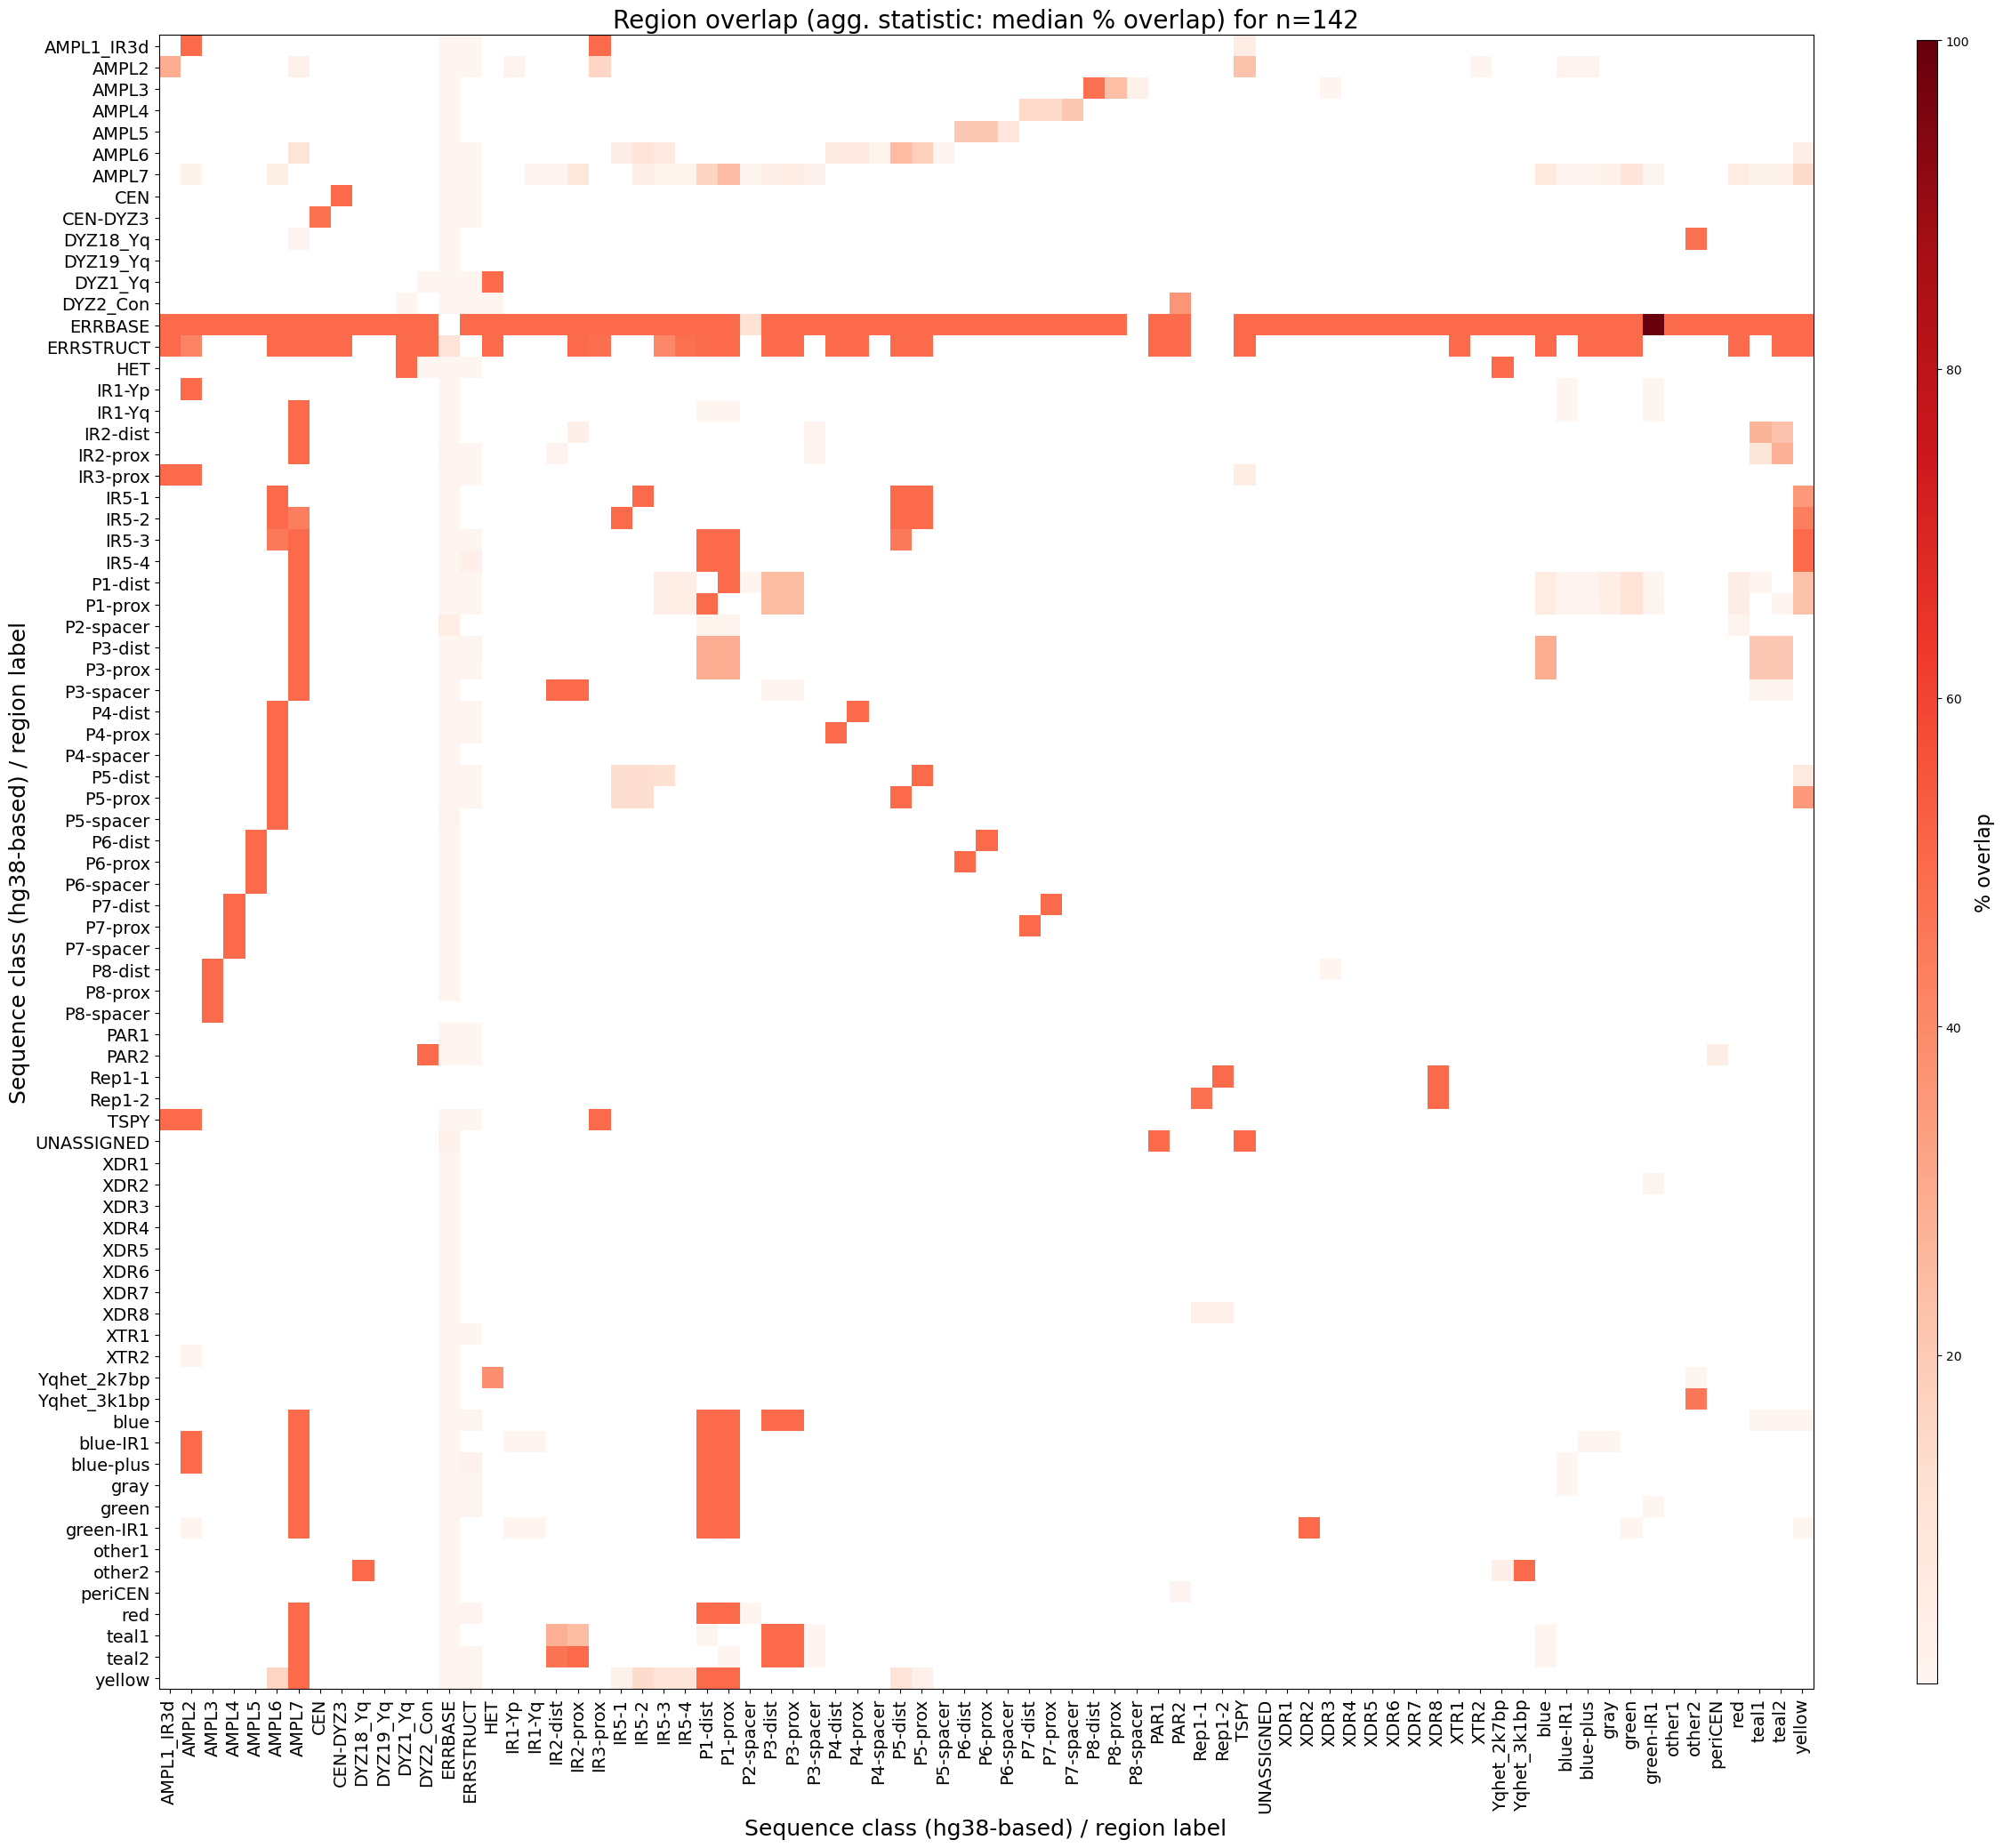

In [3]:
import pathlib as pl

cfg_nb = pl.Path("../../../load-config.ipynb").resolve(strict=True)
%run $cfg_nb

_NB_SESSION = __session__
NB_NAME = pl.Path(_NB_SESSION).name
NB_PATH = pl.Path(_NB_SESSION).parent
NB_REL_PATH = NB_PATH.relative_to(CONFIG["project_repo"]).joinpath(NB_NAME)

PLOT_ROOT = CONFIG["plot_root"].joinpath(NB_PATH.stem)
NB_CACHE_FOLDER = CONFIG["nb_cache_folder"]
DATA_ROOT = CONFIG["project_data"]

# NB-code

import pandas as pd
import numpy as np
import numpy.ma as msk
import functools as fnt

import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt

# output file of module
# rules::80_statistics::merge_self_overlap_stats

refs = ["t2tv2", "hg38"]

def parse_ref_regions(refname):

    if refname == "t2tv2":
        rel_path = pl.Path("annotation", "norm", "HG002-Y_T2Tv2_regions_repeat-details.bed")
    elif refname == "hg38":
        rel_path = pl.Path("annotation", "norm", "GRCh38-Y_regions_repeat-details.bed")
    else:
        raise ValueError(refname)
    
    ref_file = CONFIG["project_repo"].joinpath(rel_path)

    regions = pd.read_csv(ref_file, sep="\t", header=0)
    region_order = dict()
    counter = 0
    for row in regions.itertuples():
        if row.seqclass in region_order:
            continue
        region_order[row.seqclass] = counter
        counter += 1
    return region_order


def assign_order_number(region_order, region_name):
    try:
        on = region_order[region_name]
    except KeyError:
        if region_name == "UNASSIGNED":
            on = max(region_order.values()) + 1
        elif region_name == "NGAP":
            on = max(region_order.values()) + 2
        elif region_name == "ERRBASE":
            on = max(region_order.values()) + 3
        elif region_name == "ERRSTRUCT":
            on = max(region_order.values()) + 4
        else:
            raise
    return on


for ref in refs:
    #region_order = parse_ref_regions(ref)
    #assign_order = fnt.partial(assign_order_number, *(region_order,))
    filename = DATA_ROOT.joinpath("wf-data", "region-labels", "label_stats", f"{ref}.self-ovl-stats.tsv")
    df = pd.read_csv(filename, sep="\t", header=0)
    num_samples = df["sample"].nunique()
    df = df.loc[df["seq_type"] == "main", :].copy()
    agg = df.groupby(["name", "name2"])["overlap_pct"].agg(
        median="median",
        mean="mean",
        stddev="std"
    )
    agg["stddev"] = agg["stddev"].fillna(0., inplace=False)

    nuniq = df["name"].nunique()
    heatmap = np.zeros((nuniq, nuniq), dtype=float)

    labels = agg.index.get_level_values("name").unique().sort_values()

    for l1_idx, l1 in enumerate(labels, start=0):
        for l2_idx, l2 in enumerate(labels, start=0):
            try:
                value = agg.loc[(l1, l2), "median"]
            except KeyError:
                if l1 == l2:
                    value = 0  # TODO: 101 not working; set_over("black")
                else:
                    # heatmap init w/ zero anyway
                    continue            
            heatmap[l1_idx, l2_idx] = value

    colormatrix = msk.masked_where(heatmap == 0, heatmap, copy=True)
    
    cmap = cm.Reds
    cmap.set_bad("white")
    cmap.set_under("white")
    cmap.set_over("black")
    norm = mpl.colors.Normalize(vmin=1e-5, vmax=100, clip=False)
    mapper = cm.ScalarMappable(norm=norm, cmap=cmap)

    fig, ax = plt.subplots(figsize=(30,30))

    ax.imshow(
        colormatrix,
        cmap=cmap,
        colorizer=mapper
    )
    ax.set_title(f"Region overlap (agg. statistic: median % overlap) for n={num_samples}", fontsize=20)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels, fontsize=14)
    ax.set_xticklabels(labels, fontsize=14, rotation=90)
    ax.set_xlabel(f"Sequence class ({ref}-based) / region label", fontsize=18)
    ax.set_ylabel(f"Sequence class ({ref}-based) / region label", fontsize=18)
    cb = fig.colorbar(
        cm.ScalarMappable(norm=norm, cmap=cmap),
        ax=ax, orientation='vertical',
        aspect=80, shrink=0.8,
    )
    cb.set_label("% overlap", fontsize=16)
    out_path = PLOT_ROOT.joinpath("region-self-overlap", f"{ref}.region-overlap-heatmap.png")
    out_path.parent.mkdir(exist_ok=True, parents=True)
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
